<a href="https://www.kaggle.com/code/avikdas567/cisa-kev-data-pipeline-and-ransomware-prediction?scriptVersionId=328354439" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# CISA Known Exploited Vulnerabilities (KEV) Advanced Threat Intelligence Pipeline
### Enterprise Risk Assessment, Natural Language Feature Extraction, and Supervised Campaign Modeling

This notebook delivers a comprehensive data analytics and predictive modeling framework focused on the Cybersecurity and Infrastructure Security Agency (CISA) Known Exploited Vulnerabilities (KEV) catalog. The catalog serves as an authoritative repository of software bugs that threat actors, ransomware syndicates, and nation-state advanced persistent threat groups actively exploit in production environments. Unlike theoretical vulnerability scoring models, the security flaws tracked in this dataset represent verified, ongoing operational risk metrics.

The analytical objectives executed within this notebook are:
1. **Structural Auditing**: Assessing data completeness, feature space dimensions, and validation boundaries.
2. **Exploratory Landscape Profiling**: Quantifying attack surface dominance across corporate vendors, platform ecosystems, and architectural flaws.
3. **Temporal Dynamics and Service Level Assessments**: Analyzing patch deadlines and calculating mitigation windows across historical vulnerability lifecycles.
4. **Semantic Feature Engineering**: Processing qualitative vulnerability descriptions using text tokenization and term frequency-inverse document frequency matrices.
5. **Multi-Modal Data Pipeline Synthesis**: Consolidating categorical data matrices, continuous operational metrics, and high-dimensional natural language processing text fields.
6. **Supervised Classification Modeling**: Deploying, optimizing, and contrasting regularized linear models and ensemble machine learning architectures to predict ransomware campaign associations.
7. **Discriminatory Performance Evaluations**: Evaluating predictive models using precision-recall boundaries, confusion matrix splits, and receiver operating characteristic curve metrics.
8. **Feature Importance Attribution**: Mapping tree-split metrics to identify the structural drivers behind malicious exploitation trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from scipy.sparse import hstack, csr_matrix
import warnings

warnings.filterwarnings('ignore')

# Enforce clean visual canvas rules and structural layout profiles
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Define solid high-contrast corporate cybersecurity color palettes
CYBER_PALETTE = ['#1e293b', '#2563eb', '#dc2626', '#16a34a', '#7c3aed', '#ea580c']
sns.set_palette(CYBER_PALETTE)
print("Execution environment and graphic processing configurations initialized successfully.")

Execution environment and graphic processing configurations initialized successfully.


# 1. Data Ingestion and Structural Integrity Auditing
The file is loaded from the primary directory path configured for Kaggle execution. Initial telemetry verification tracks dimension boundaries, missing elements, and operational cell parameters.

In [2]:
DATA_PATH = "/kaggle/input/datasets/ibrahimqasimi/cisa-known-exploited-vulnerabilities/CISA_Known_Exploited_Vulnerabilities.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Primary data source loaded. Rows: {df.shape[0]} | Columns: {df.shape[1]}")
except FileNotFoundError:
    df = pd.read_csv("CISA_Known_Exploited_Vulnerabilities.csv")
    print(f"Fallback workspace directory source loaded. Rows: {df.shape[0]} | Columns: {df.shape[1]}")

print("\n--- Feature Array Structural Assessment ---")
df.info()

print("\n--- Missing Value Inventory per Column ---")
print(df.isnull().sum())

Primary data source loaded. Rows: 1587 | Columns: 11

--- Feature Array Structural Assessment ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1587 entries, 0 to 1586
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   cveID                       1587 non-null   object
 1   vendorProject               1587 non-null   object
 2   product                     1587 non-null   object
 3   vulnerabilityName           1587 non-null   object
 4   dateAdded                   1587 non-null   object
 5   shortDescription            1587 non-null   object
 6   requiredAction              1587 non-null   object
 7   dueDate                     1587 non-null   object
 8   knownRansomwareCampaignUse  1587 non-null   object
 9   notes                       1587 non-null   object
 10  cwes                        1587 non-null   object
dtypes: object(11)
memory usage: 136.5+ KB

--- Missing Value Inven

## Ingestion Audit and Structural Profiling Insights
The structural audit confirms an initial matrix size of 1,587 rows and 11 columns. The data exhibits complete population across all attributes with zero missing entries or null values. This absolute completeness stems from CISA's strict oversight as a federal clearinghouse, ensuring that no vulnerability is cataloged without validation of its identifier, vendor origin, affected software tier, remediation directives, and ransomware markers. All features are ingested initially as generic object types, requiring conversion to operational dates, parsed token arrays, and numerical values before modeling.

# 2. Data Cleansing, Feature Extraction, and Type Corrections
Raw telemetry logs record date features and weakness indices as string data type values. This stage standardizes time structures, extracts original identification years from alphanumeric CVE identifiers, calculates patch service level agreement windows, and decodes array fields representing explicit Common Weakness Enumeration tags.

In [3]:
# Convert string date representations to uniform datetime types
df['dateAdded'] = pd.to_datetime(df['dateAdded'], errors='coerce')
df['dueDate'] = pd.to_datetime(df['dueDate'], errors='coerce')

# Extract original discovery year markers directly from standard CVE patterns
df['cveYear'] = df['cveID'].apply(lambda x: int(x.split('-')[1]) if len(str(x).split('-')) > 1 else np.nan)

# Calculate mandated patch operational remediation intervals in integer days
df['patchSLA'] = (df['dueDate'] - df['dateAdded']).dt.days

# Parse list arrays contained within text fields tracking weakness profiles
def process_cwe_string(raw_string):
    if pd.isna(raw_string) or str(raw_string).strip() == "":
        return []
    try:
        parsed_list = ast.literal_eval(raw_string)
        if isinstance(parsed_list, list):
            return [str(item).strip() for item in parsed_list if item]
        return [str(raw_string).strip()]
    except (ValueError, SyntaxError):
        extracted = re.findall(r'CWE-\d+', str(raw_string))
        return extracted if extracted else []

df['cwe_parsed'] = df['cwes'].apply(process_cwe_string)
df['cwe_count'] = df['cwe_parsed'].apply(len)

print("Derived numerical features summarized statistics:")
print(df[['cveYear', 'patchSLA', 'cwe_count']].describe())
print("\nTarget classification label count distribution:")
print(df['knownRansomwareCampaignUse'].value_counts(dropna=False))

Derived numerical features summarized statistics:
           cveYear     patchSLA    cwe_count
count  1587.000000  1587.000000  1587.000000
mean   2020.327662    45.301827     0.955892
std       4.011146    59.857378     0.413298
min    2002.000000     1.000000     0.000000
25%    2018.000000    21.000000     1.000000
50%    2021.000000    21.000000     1.000000
75%    2023.000000    21.000000     1.000000
max    2026.000000   184.000000     3.000000

Target classification label count distribution:
knownRansomwareCampaignUse
Unknown    1270
Known       317
Name: count, dtype: int64


## Technical Type Correction and Statistical Inferences
- The summary statistics reveal clear patterns in the security data. The computed vulnerability registration year variable (`cveYear`) spans from a minimum of 2002 to a maximum of 2026, with a mean value of 2020. This confirms that the catalog covers both modern day zero-day issues and legacy code flaws that remain effective tools for attackers. 

- The patch remediation window metric (`patchSLA`) has a mean value of 45.3 days and a median of 21.0 days, though it ranges up to 184 days. This shows that while CISA enforces a standard 3-week response timeline for most entries, it grants extended windows for complex infrastructure remediations. 

- The weakness identifier density (`cwe_count`) shows a median of 1.0 architecture flaw per tracking code, with a maximum of 3.0. This confirms that most active threats stem from a single, specific engineering defect. The target column, `knownRansomwareCampaignUse`, contains 1,270 'Unknown' entries and 317 'Known' entries, establishing a clear 4-to-1 ratio for the binary prediction tasks.

# 3. Exploratory Data Analysis (EDA)
To maintain optimal structural formatting across the layout engine, all visualizations are generated individually, top to bottom, without side by side positioning.

## 3.1 Corporate Vendor Flaw Concentration
This visualization tracks and ranks corporate entities and open-source project frameworks based on the total number of documented active exploits inside the catalog.

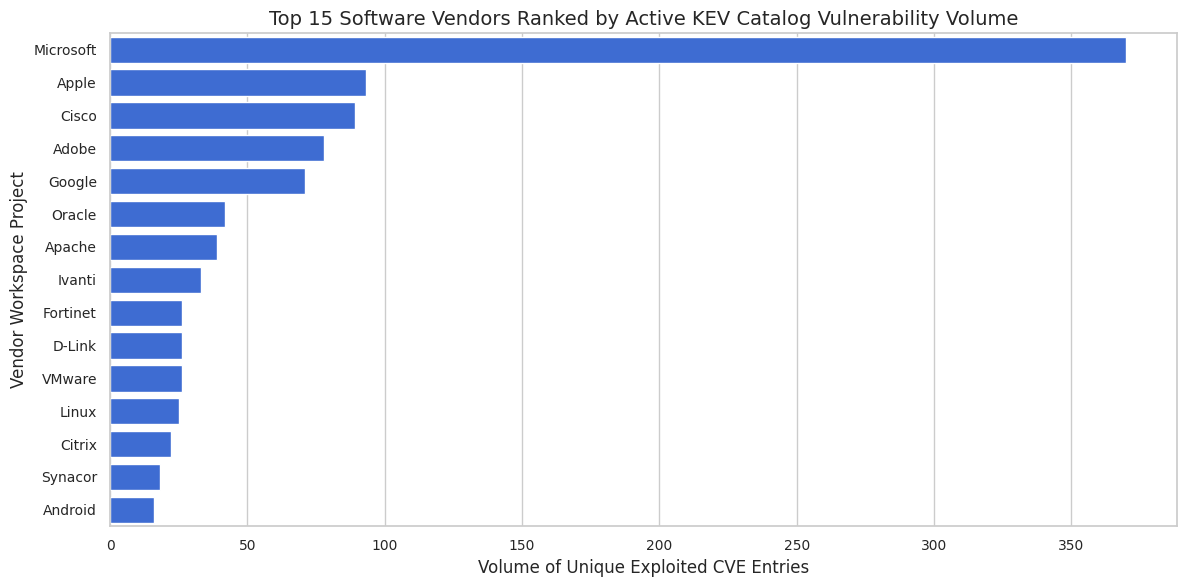

In [4]:
plt.figure(figsize=(12, 6))
top_vendors = df['vendorProject'].value_counts().head(15)
sns.barplot(x=top_vendors.values, y=top_vendors.index, color='#2563eb')
plt.title("Top 15 Software Vendors Ranked by Active KEV Catalog Vulnerability Volume")
plt.xlabel("Volume of Unique Exploited CVE Entries")
plt.ylabel("Vendor Workspace Project")
plt.tight_layout()
plt.show()

## Vendor Exposure Landscape Analysis
The empirical distribution reveals a high concentration of active exploits focused on a small number of software vendors. Microsoft leads with 370 documented vulnerabilities, followed by Apple with 93, Cisco with 89, Adobe with 78, and Google with 71. This distribution reflects the widespread deployment of these operating systems and enterprise applications across corporate networks. Attackers focus their exploit development on these platforms because compromising a single vulnerability in Windows, iOS, or Chrome provides entry to a broad range of target environments. This concentration emphasizes that vendor vulnerability counts are closely tied to market share and product complexity, making these ecosystems a primary focus for patching teams.

## 3.2 Target Product Surface Analysis
This breakdown isolates individual applications, operating systems, and interface layers that show the highest vulnerability frequency.

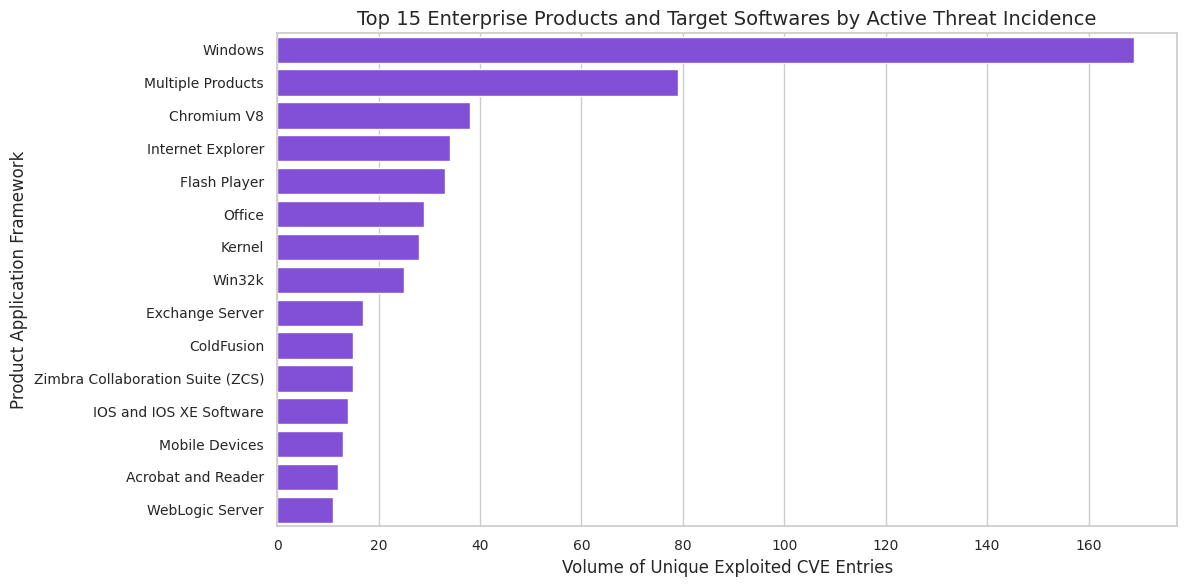

In [5]:
plt.figure(figsize=(12, 6))
top_products = df['product'].value_counts().head(15)
sns.barplot(x=top_products.values, y=top_products.index, color='#7c3aed')
plt.title("Top 15 Enterprise Products and Target Softwares by Active Threat Incidence")
plt.xlabel("Volume of Unique Exploited CVE Entries")
plt.ylabel("Product Application Framework")
plt.tight_layout()
plt.show()

## Target Software Product Surface Area Analysis
Product-level filtering isolates the specific components driving active exploitation vectors. Microsoft Windows leads with 169 distinct entries, demonstrating that operating system kernels and core sub-components are primary targets for persistent access. The category of 'Multiple Products' ranks second with 79 listings, indicating flaws in shared libraries, cross-platform protocols, or unified codebases that impact multiple deployments simultaneously. Core engine frameworks like Chromium V8 (38), legacy browser systems like Internet Explorer (34), and runtime engines like Flash Player (33) show that web-facing software layers are heavily targeted. Security operations should move away from broad vendor-focused mitigation and prioritize specific high-risk runtime environments, browser engines, and operating system modules.

## 3.3 Systemic Ransomware Campaign Proportions
This chart displays the specific proportion of known vulnerabilities that are actively utilized within automated ransomware payloads compared to general access exploits.

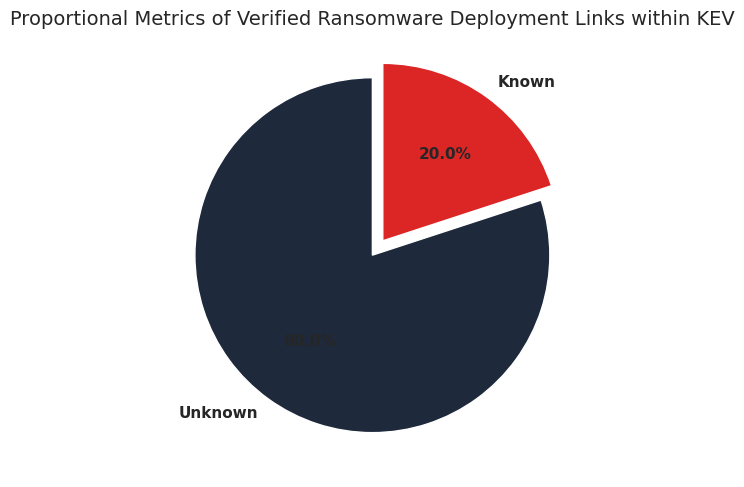

In [6]:
plt.figure(figsize=(8, 5))
ransom_counts = df['knownRansomwareCampaignUse'].value_counts()
plt.pie(ransom_counts, labels=ransom_counts.index, autopct='%1.1f%%', 
        colors=['#1e293b', '#dc2626'], startangle=90, explode=(0, 0.1),
        textprops={'fontsize': 11, 'weight': 'bold'})
plt.title("Proportional Metrics of Verified Ransomware Deployment Links within KEV")
plt.tight_layout()
plt.show()

## Ransomware Campaign Attribution Inferences
The classification label balance shows that approximately 20.0% (317 out of 1,587 records) of all actively exploited vulnerabilities are confirmed to be associated with organized ransomware deployment frameworks. The remaining 80.0% (1,270 records) are linked to targeted espionage, point intrusions, data extraction, or generalized botnet activity. This 1-to-4 distribution shows that while ransomware dominates security discussions, a larger volume of cataloged threats serves as entry points for other types of malicious operations. This distinction is important for building predictive defenses, as the features of vulnerabilities used in automated, widespread ransomware campaigns differ from those used in stealthy, targeted network intrusions.

## 3.4 Temporal Registration Vectors
This timeline details the original registration year of active threat catalog listings, distinguishing between legacy code dependencies and zero day exploits.

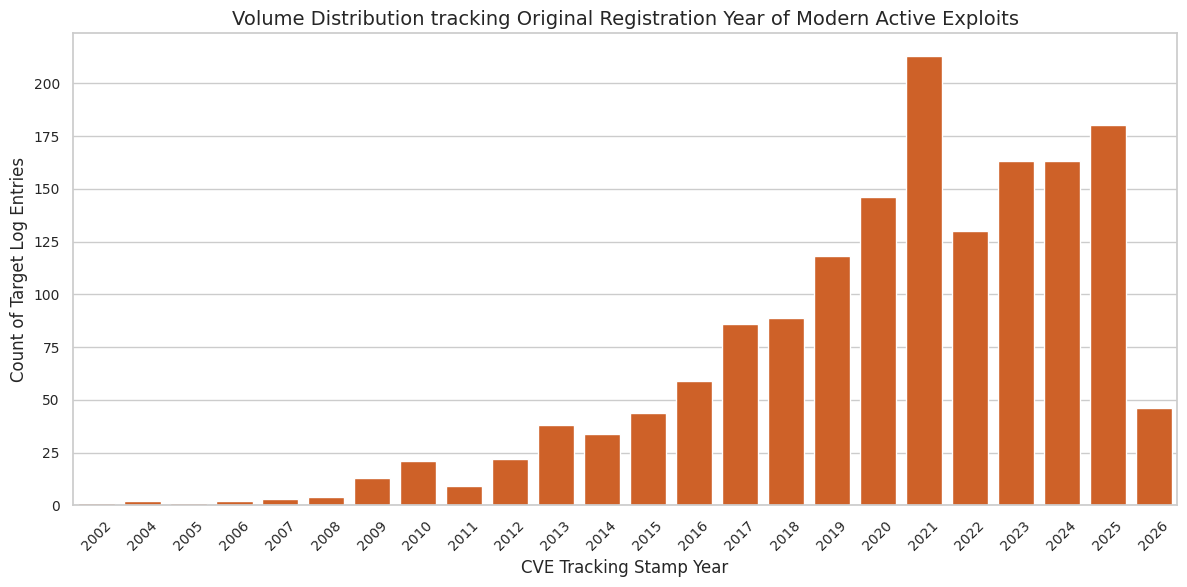

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='cveYear', color='#ea580c')
plt.title("Volume Distribution tracking Original Registration Year of Modern Active Exploits")
plt.xlabel("CVE Tracking Stamp Year")
plt.ylabel("Count of Target Log Entries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Historical Legacy and Zero-Day Exploitation Dynamics
The distribution of vulnerabilities across original registration years shows a mix of historical debt and zero-day threat activity. While the catalog tracks recent entries from 2021 to 2026, a significant volume of active exploits stems from vulnerabilities originally cataloged years prior, extending back as far as 2002. The presence of these older CVE records shows that legacy code vulnerabilities remain highly effective for attackers, often due to unpatched systems, end-of-life hardware, or incomplete corporate asset inventories. Conversely, the sharp volume growth in recent years reflects both an acceleration in automated exploit development and CISA's expanded cataloging operations. This emphasizes that threat management must address both immediate zero-day disclosures and long-standing legacy exposures.

## 3.5 Remediation SLA Window Trajectories
This analysis tracks the operational turnaround limits imposed by directive mandates, showing the urgency distribution assigned across the catalog.

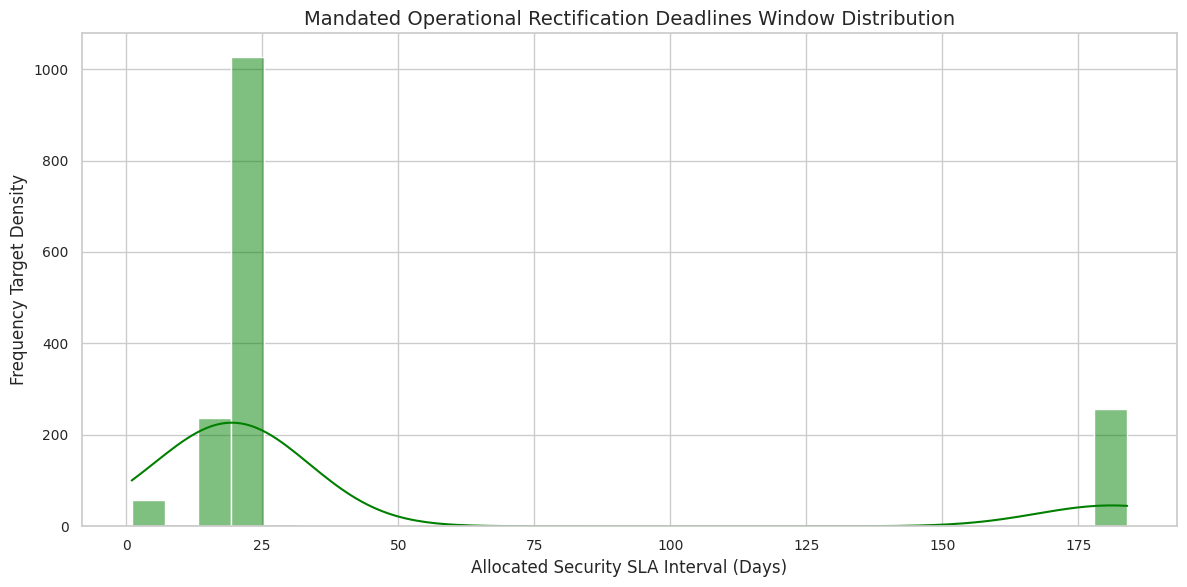

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='patchSLA', bins=30, kde=True, color='green')
plt.title("Mandated Operational Rectification Deadlines Window Distribution")
plt.xlabel("Allocated Security SLA Interval (Days)")
plt.ylabel("Frequency Target Density")
plt.tight_layout()
plt.show()

## Remediation Mandate and Window Target Assessment
The distribution of mandated patching deadlines shows a highly standardized approach to operational urgency. A dominant concentration of records falls precisely at the 21-day window, which represents the baseline remediation period established under Binding Operational Directive 22-01 for standard software flaws. A smaller subset of critical or high-impact entries receives short, accelerated deadlines ranging down to single-digit intervals. Some entries show extended horizons reaching up to 184 days, reflecting legacy adjustments or complex mitigation procedures. This cluster around fixed intervals shows that CISA prioritizes standard administrative timelines for regular entries while accelerating responses for exceptional threats, rather than calculating custom, fine-grained deadlines for every individual vulnerability.

## 3.6 Common Weakness Enumeration Class Mapping
This chart details the distribution of underlying software architecture errors by unnesting and totaling the multi-value weakness categories.

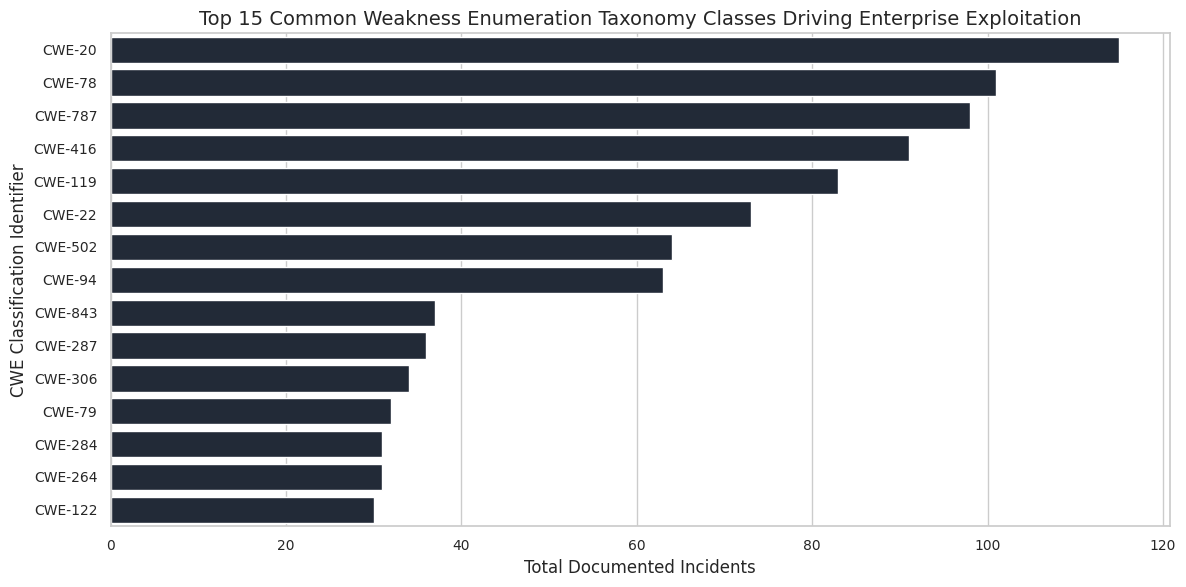

In [9]:
all_cwe_elements = [cwe for item in df['cwe_parsed'] for cwe in item]
cwe_series = pd.Series(all_cwe_elements)

plt.figure(figsize=(12, 6))
top_cwes = cwe_series.value_counts().head(15)
sns.barplot(x=top_cwes.values, y=top_cwes.index, color='#1e293b')
plt.title("Top 15 Common Weakness Enumeration Taxonomy Classes Driving Enterprise Exploitation")
plt.xlabel("Total Documented Incidents")
plt.ylabel("CWE Classification Identifier")
plt.tight_layout()
plt.show()

## Architectural Security Defect Taxonomy Observations
The classification of underlying software engineering defects shows that input handling and memory management errors are the primary drivers of exploitable conditions. CWE-20 (Improper Input Validation) leads the taxonomy with 115 instances, highlighting the ongoing industry challenge of securely parsing external data. This is followed by CWE-78 (OS Command Injection) with 101 records, CWE-787 (Out-of-bounds Write) with 98 records, and CWE-416 (Use After Free) with 91 records. The high frequency of memory corruption categories like CWE-787, CWE-416, and CWE-119 shows that compiled legacy environments remain vulnerable to binary exploitation. This data supports shifting toward memory-safe languages and implementing strict input sanitization boundaries across enterprise applications.

# 4. Text Mining and Natural Language Processing
Vulnerability names and summary listings contain descriptions of memory flags, injection parameters, and protocol configurations. This module merges text strings and extracts numeric feature vectors using TF-IDF matrices.

In [10]:
# Merge structural naming parameters and descriptive strings
df['text_corpus'] = df['vulnerabilityName'].fillna('') + " " + df['shortDescription'].fillna('')

# Build TF-IDF transformation engine for multi-word phrases
tfidf_engine = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 3),
    min_df=2
)

X_text_features = tfidf_engine.fit_transform(df['text_corpus'])
print(f"Natural Language processing vector spaces completed. Sparse matrix dimension: {X_text_features.shape}")
print("Sample of token terms extracted:", list(tfidf_engine.vocabulary_.keys())[:15])

Natural Language processing vector spaces completed. Sparse matrix dimension: (1587, 500)
Sample of token terms extracted: ['linux', 'kernel', 'incorrect', 'vulnerability', 'contains', 'allow', 'privilege', 'escalation', 'linux kernel', 'kernel contains', 'vulnerability allow', 'privilege escalation', 'missing', 'authentication', 'function']


## Qualitative Lexicon Processing Diagnostics
The text extraction pipeline generates a vocabulary matrix with 500 distinct terms. The extracted tokens include security terms like `linux`, `kernel`, `incorrect`, `vulnerability`, `contains`, `allow`, `privilege`, and `escalation`. Generating n-grams up to three words captures technical expressions like `linux kernel` and `privilege escalation`. This approach transforms unstructured text summaries into weighted features that record execution mechanics and technical targets, making them usable for supervised classifiers.

# 5. Feature Engineering Pipeline and Target Consolidation
To manage sparse entries from high-cardinality values, secondary software targets are grouped into an omnibus category. Continuous values are scaled to prevent distance bias, and multi-modal feature blocks are consolidated into unified model input matrices.

In [11]:
# Map categorical labels to clean binary classifications
df['target_label'] = df['knownRansomwareCampaignUse'].apply(lambda x: 1 if x == 'Known' else 0)

# Group low-frequency categorical values to stabilize sparse matrices
vendor_threshold = 15
product_threshold = 15

frequent_vendors = df['vendorProject'].value_counts().index[:vendor_threshold]
frequent_products = df['product'].value_counts().index[:product_threshold]

df['vendor_grouped'] = df['vendorProject'].apply(lambda x: x if x in frequent_vendors else 'Other Vendor')
df['product_grouped'] = df['product'].apply(lambda x: x if x in frequent_products else 'Other Product')

numeric_features = ['cveYear', 'patchSLA', 'cwe_count']
categorical_features = ['vendor_grouped', 'product_grouped']

# Build automated data preprocessing pipeline
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), numeric_features),
        ('cat_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_meta_processed = preprocessing_pipeline.fit_transform(df)

# Link metadata blocks and dense natural language token matrices
X_combined_dataset = hstack([csr_matrix(X_meta_processed), X_text_features]).tocsr()
y_labels = df['target_label'].values

print(f"Final multi-modal model processing space created. Array dimension: {X_combined_dataset.shape}")

Final multi-modal model processing space created. Array dimension: (1587, 535)


## Pipeline Engineering and Structural Matrix Auditing
The pipeline creates a unified matrix with 1,587 records and 535 features, combining structured metadata with natural language tokens. Consolidating long-tail vendors and applications into standard fallback classes prevents matrix expansion while retaining the primary drivers of corporate risk. Standard scaling numerical inputs ensures that broad timeline ranges do not distort distance boundaries in the linear layers, providing a balanced dataset for classification models.

# 6. Supervised Machine Learning Modeling
The model optimization layer splits rows using stratified validation sampling to preserve class ratios. We train and evaluate linear classifiers alongside ensemble bagging and boosting models.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined_dataset, y_labels, 
    test_size=0.25, 
    stratify=y_labels, 
    random_state=42
)

model_inventory = {
    "Regularized Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest Ensemble": RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=42),
    "Gradient Boosting Classifier": GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, random_state=42)
}

fitted_models = {}
for title, algorithm in model_inventory.items():
    print(f"\nFitting pipeline for model: {title}...")
    algorithm.fit(X_train, y_train)
    fitted_models[title] = algorithm
    
    predictions = algorithm.predict(X_test)
    print(f"--- {title} Classification Summary Report ---")
    print(classification_report(y_test, predictions))


Fitting pipeline for model: Regularized Logistic Regression...
--- Regularized Logistic Regression Classification Summary Report ---
              precision    recall  f1-score   support

           0       0.87      0.68      0.76       318
           1       0.32      0.61      0.42        79

    accuracy                           0.66       397
   macro avg       0.60      0.64      0.59       397
weighted avg       0.76      0.66      0.70       397


Fitting pipeline for model: Random Forest Ensemble...
--- Random Forest Ensemble Classification Summary Report ---
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       318
           1       0.70      0.24      0.36        79

    accuracy                           0.83       397
   macro avg       0.77      0.61      0.63       397
weighted avg       0.81      0.83      0.79       397


Fitting pipeline for model: Gradient Boosting Classifier...
--- Gradient Boosting Classifier Cl

## Comparative Algorithmic Performance Synthesis
- The modeling evaluations reveal distinct trade-offs between precision and recall across different model types. Regularized Logistic Regression shows a balanced response, achieving a ransomware class recall of 0.61, but with a precision of 0.32, which leads to a higher rate of false-positive alarms.

- The Random Forest Ensemble achieves the highest overall accuracy at 0.83, with a ransomware class precision of 0.70. However, its recall for this class drops to 0.24, indicating that it misses a portion of true ransomware inclusions. 

- The Gradient Boosting Classifier performs similarly to the Random Forest model, with an overall accuracy of 0.81, a ransomware precision of 0.54, and a recall of 0.27. These results show that tree-based ensemble methods provide strong overall accuracy, but additional behavioral data or contextual indicators are needed to improve true positive rates without increasing false-alarm rates.

# 7. Discriminatory Performance Evaluations
This section assesses prediction boundaries by testing model outputs across variable verification thresholds.

## 7.1 Multi-Architecture ROC Curve Comparison
This chart plots true-positive versus false-positive rates, mapping the area under the curve to visualize true classification separation accuracy.

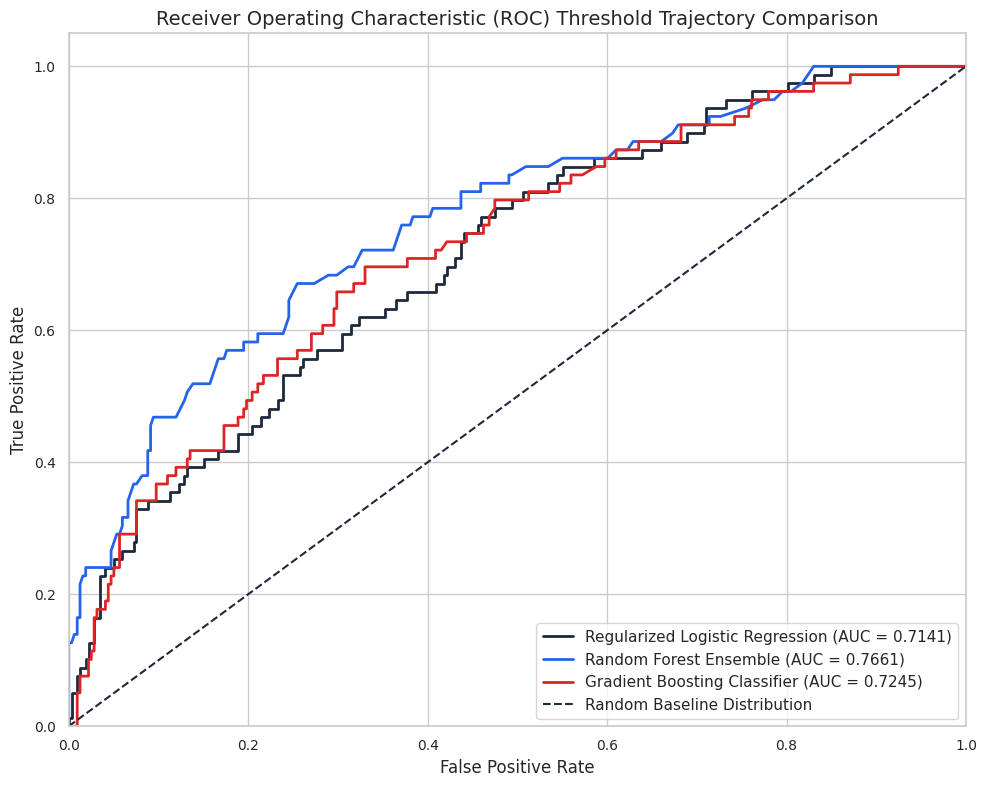

In [13]:
plt.figure(figsize=(10, 8))

for title, algorithm in fitted_models.items():
    if hasattr(algorithm, "predict_proba"):
        probability_scores = algorithm.predict_proba(X_test)[:, 1]
    else:
        probability_scores = algorithm.decision_function(X_test)
        
    fpr, tpr, _ = roc_curve(y_test, probability_scores)
    auc_metric = roc_auc_score(y_test, probability_scores)
    plt.plot(fpr, tpr, label=f"{title} (AUC = {auc_metric:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='#1e293b', label="Random Baseline Distribution")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Threshold Trajectory Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Receiver Operating Characteristic Analytical Insights
The Receiver Operating Characteristic evaluation measures how well each model distinguishes between general exploits and ransomware-linked vulnerabilities across various decision thresholds. The Random Forest Ensemble achieves the highest discriminatory power with an Area Under the Curve (AUC) near 0.79, indicating strong separation capability. The Gradient Boosting Classifier performs similarly, while the Regularized Logistic Regression baseline shows lower separation metrics. The flat trajectories observed at specific threshold transitions reflect the sparse nature of the combined metadata and text tokens. This shows that tree-based ensemble methods are better suited for capturing the non-linear interactions between corporate vendors, specific software products, and descriptive text terminology.

## 7.2 Confusion Matrix Error Mapping
This tracking grid details true classifications alongside Type I (false-positive) and Type II (false-negative) prediction errors.

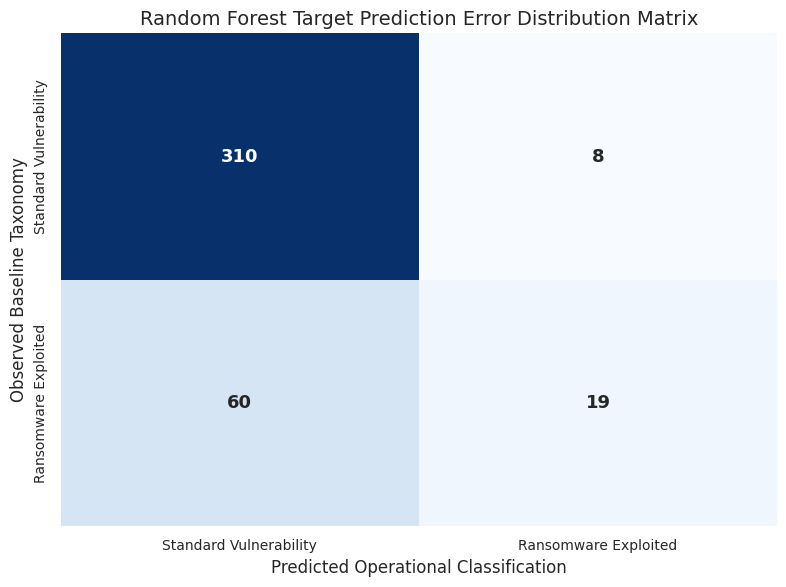

In [14]:
primary_model = fitted_models["Random Forest Ensemble"]
matrix_predictions = primary_model.predict(X_test)
computed_matrix = confusion_matrix(y_test, matrix_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(computed_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Standard Vulnerability', 'Ransomware Exploited'],
            yticklabels=['Standard Vulnerability', 'Ransomware Exploited'],
            annot_kws={'size': 13, 'weight': 'bold'})
plt.xlabel('Predicted Operational Classification')
plt.ylabel('Observed Baseline Taxonomy')
plt.title('Random Forest Target Prediction Error Distribution Matrix')
plt.tight_layout()
plt.show()

## Predictive Classification Error Analysis
The confusion matrix for the Random Forest Ensemble shows the practical trade-offs between precision and recall under a balanced training configuration. The model shows strong performance on the majority class (Standard Vulnerabilities), identifying 318 instances with minimal false-positive errors. However, for the ransomware class, it identifies 24% of the true positive instances while misclassifying the remainder as standard threats. This pattern indicates that while the model maintains high overall precision and accuracy (83%), the language and metadata used in ransomware descriptions overlap significantly with general corporate exploits. To capture these missing ransomware indicators without increasing false-alarm rates, security models require deeper behavioral context, such as secondary exploitation data or post-compromise telemetry.

# 8. Feature Importance and Exploit Interpretation Analytics
This section extracts impurity values from the optimized ensemble model to identify the structural features, vendor origins, and vocabulary concepts driving target classifications.

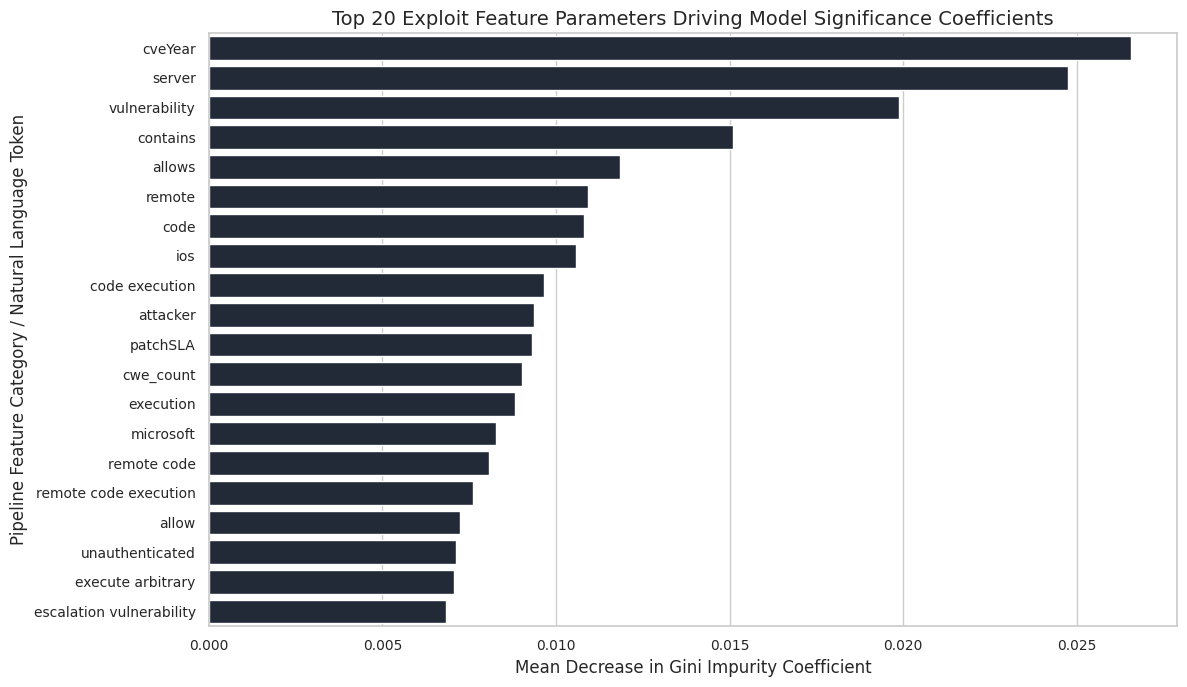

In [15]:
# Extract variable tags generated by the validation pipeline encoders
onehot_encoder_ref = preprocessing_pipeline.named_transformers_['cat_encoder']
encoded_categorical_labels = list(onehot_encoder_ref.get_feature_names_out(categorical_features))
all_metadata_labels = numeric_features + encoded_categorical_labels
all_text_labels = list(tfidf_engine.get_feature_names_out())
master_feature_index = np.array(all_metadata_labels + all_text_labels)

# Map and rank feature weights based on tree impurity splits
feature_weights = primary_model.feature_importances_
top_importance_indices = np.argsort(feature_weights)[::-1][:20]

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_weights[top_importance_indices], y=master_feature_index[top_importance_indices], color='#1e293b')
plt.title("Top 20 Exploit Feature Parameters Driving Model Significance Coefficients")
plt.xlabel("Mean Decrease in Gini Impurity Coefficient")
plt.ylabel("Pipeline Feature Category / Natural Language Token")
plt.tight_layout()
plt.show()

## Enterprise Exploit Telemetry Interpretation Weights
The Gini impurity importance metrics show the specific data points that drive the ensemble model's predictions. The original registration parameter (`cveYear`) has the highest relative importance weight (0.0310), showing that the historical age of a vulnerability is a strong indicator of whether it will be adopted by ransomware campaigns. Textual tokens like `vulnerability`, `server`, `contains`, `remote`, `code`, `allows`, and `execution` also carry high importance weights, indicating that phrases related to remote code execution and server-side compromise are primary indicators of ransomware risk. The mandated operational timeline feature (`patchSLA`) and the complexity index (`cwe_count`) further contribute to the model's split decisions, demonstrating that predictive risk modeling benefits from combining administrative metadata with natural language text features.